<a href="https://colab.research.google.com/github/ropafadzonyadome-ui/Assignment-/blob/main/HAcs409_Derivative_Pricing_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HAcs 409 — Financial Engineering and Capital Markets
## Derivative Pricing: Assigmment 1

**Base case:** S0 = 100, K = 100, r = 5%, T = 3 months, σ = 20%.


**Numerical conventions:** 500-step CRR/trinomial trees; 300,000 antithetic Monte-Carlo paths and 60 time steps for path simulation; stock bump h = $1 for numerical Greeks; option prices displayed to the nearest cent. The Heston/Merton terminal simulations use a martingale correction so the simulated discounted stock is consistent with the risk-neutral forward and put-call parity is preserved to rounding.

In [ ]:

import math, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display

S0=100.; K0=100.; r=.05; T=.25; sigma0=.20
N_TREE=500; MC_PATHS=300_000; MC_STEPS=60

def parity_rhs(S,K,r,T): return S-K*math.exp(-r*T)

def binomial_tree(S0,K,r,T,sigma,N,option='call',american=False):
    dt=T/N; u=math.exp(sigma*math.sqrt(dt)); d=1/u
    p=(math.exp(r*dt)-d)/(u-d); disc=math.exp(-r*dt)
    j=np.arange(N+1); ST=S0*u**j*d**(N-j)
    V=np.maximum(ST-K,0) if option=='call' else np.maximum(K-ST,0)
    for i in range(N-1,-1,-1):
        j=np.arange(i+1); V=disc*(p*V[1:i+2]+(1-p)*V[:i+1])
        if american:
            S=S0*u**j*d**(i-j); intr=np.maximum(S-K,0) if option=='call' else np.maximum(K-S,0)
            V=np.maximum(V,intr)
    return float(V[0]),u,d,p

def european_binomial_full(S0,K,r,T,sigma,N,option='put'):
    dt=T/N; u=math.exp(sigma*math.sqrt(dt)); d=1/u
    p=(math.exp(r*dt)-d)/(u-d); disc=math.exp(-r*dt); vals={}; deltas={}
    for j in range(N+1):
        S=S0*u**j*d**(N-j); vals[N,j]=max(S-K,0) if option=='call' else max(K-S,0)
    for i in range(N-1,-1,-1):
        for j in range(i+1):
            S=S0*u**j*d**(i-j)
            vals[i,j]=disc*(p*vals[i+1,j+1]+(1-p)*vals[i+1,j])
            deltas[i,j]=(vals[i+1,j+1]-vals[i+1,j])/(S*u-S*d)
    return vals,deltas,u,d,p,disc

def american_binomial_full(S0,K,r,T,sigma,N,option='put'):
    dt=T/N; u=math.exp(sigma*math.sqrt(dt)); d=1/u
    p=(math.exp(r*dt)-d)/(u-d); disc=math.exp(-r*dt)
    vals={}; deltas={}; exercise={}
    for j in range(N+1):
        S=S0*u**j*d**(N-j); vals[N,j]=max(S-K,0) if option=='call' else max(K-S,0)
    for i in range(N-1,-1,-1):
        for j in range(i+1):
            S=S0*u**j*d**(i-j)
            cont=disc*(p*vals[i+1,j+1]+(1-p)*vals[i+1,j])
            intr=max(S-K,0) if option=='call' else max(K-S,0)
            vals[i,j]=max(cont,intr); exercise[i,j]=intr>cont+1e-12
            deltas[i,j]=(vals[i+1,j+1]-vals[i+1,j])/(S*u-S*d)
    return vals,deltas,exercise,u,d,p,disc

def trinomial_tree(S0,K,r,T,sigma,N,option='call'):
    dt=T/N; dx=sigma*math.sqrt(2*dt); u=math.exp(dx); d=1/u
    a=math.exp(sigma*math.sqrt(dt/2)); b=math.exp(-sigma*math.sqrt(dt/2)); ed=math.exp(r*dt/2)
    pu=((ed-b)/(a-b))**2; pd=((a-ed)/(a-b))**2; pm=1-pu-pd; disc=math.exp(-r*dt)
    k=np.arange(-N,N+1); S=S0*np.exp(k*dx); V=np.maximum(S-K,0) if option=='call' else np.maximum(K-S,0)
    for _ in range(N): V=disc*(pd*V[:-2]+pm*V[1:-1]+pu*V[2:])
    return float(V[0])

def heston_ratio_paths(r,T,v0,kappa,theta,xi,rho,n_paths=MC_PATHS,n_steps=MC_STEPS,seed=42):
    rng=np.random.default_rng(seed); dt=T/n_steps; m=(n_paths+1)//2; n=2*m
    v=np.full(n,v0); logR=np.zeros(n)
    for _ in range(n_steps):
        z1=rng.standard_normal(m); z2=rng.standard_normal(m)
        z1=np.concatenate([z1,-z1]); z2=np.concatenate([z2,-z2])
        vs=np.maximum(v,0); zS=rho*z1+math.sqrt(1-rho*rho)*z2
        logR+=(r-.5*vs)*dt+np.sqrt(vs*dt)*zS
        v=np.maximum(v+kappa*(theta-vs)*dt+xi*np.sqrt(vs*dt)*z1,0)
    return np.exp(logR)[:n_paths]

def merton_ratio_paths(r,T,sigma,lam,mu,delta,n_paths=MC_PATHS,seed=123):
    rng=np.random.default_rng(seed); Z=rng.standard_normal(n_paths); N=rng.poisson(lam*T,n_paths)
    J=N*mu+np.sqrt(N)*delta*rng.standard_normal(n_paths); kJ=math.exp(mu+.5*delta**2)-1
    return np.exp((r-lam*kJ-.5*sigma**2)*T+sigma*math.sqrt(T)*Z+J)

def mc_prices(R,S0,K):
    Rc=R*(math.exp(r*T)/R.mean()); ST=S0*Rc; d=math.exp(-r*T)
    return d*np.mean(np.maximum(ST-K,0)), d*np.mean(np.maximum(K-ST,0)), Rc

def heston_paths(r,T,v0,kappa,theta,xi,rho,n_paths=MC_PATHS,n_steps=MC_STEPS,seed=44):
    rng=np.random.default_rng(seed); dt=T/n_steps; m=(n_paths+1)//2; n=2*m
    v=np.full(n,v0); S=np.full(n,S0); maxS=S.copy()
    for _ in range(n_steps):
        z1=rng.standard_normal(m); z2=rng.standard_normal(m); z1=np.r_[z1,-z1]; z2=np.r_[z2,-z2]
        vs=np.maximum(v,0); zS=rho*z1+math.sqrt(1-rho*rho)*z2
        S*=np.exp((r-.5*vs)*dt+np.sqrt(vs*dt)*zS)
        v=np.maximum(v+kappa*(theta-vs)*dt+xi*np.sqrt(vs*dt)*z1,0); maxS=np.maximum(maxS,S)
    return S[:n_paths],maxS[:n_paths]

def hedge_euro(S0,K,r,T,sigma,N,moves,american=False):
    if american:
        vals,deltas,exercise,u,d,p,disc=american_binomial_full(S0,K,r,T,sigma,N,'put')
    else:
        vals,deltas,u,d,p,disc=european_binomial_full(S0,K,r,T,sigma,N,'put'); exercise={}
    i=j=0; h=deltas[0,0]; V=vals[0,0]; cash=V-h*S0
    rows=[dict(step=0,move='-',S=S0,option_value=V,delta=h,stock_position=h,cash_account=cash,exercise=False)]
    for step,move in enumerate(moves,1):
        j+=move; i=step; S=S0*u**j*d**(i-j); cash*=math.exp(r*T/N); V=vals[i,j]
        hnew=deltas[i,j] if i<N else 0.; ex=exercise.get((i,j),False)
        cash-=(hnew-h)*S
        rows.append(dict(step=i,move='U' if move else 'D',S=S,option_value=V,delta=(deltas[i,j] if i<N else 0.),stock_position=hnew,cash_account=cash,exercise=ex)); h=hnew
    return pd.DataFrame(rows),vals[0,0]

def simulate_gbm(S0,r,T,sigma,n_paths=80000,n_steps=25,seed=2026):
    rng=np.random.default_rng(seed); dt=T/n_steps; m=(n_paths+1)//2
    Z=rng.standard_normal((n_steps,m)); Z=np.c_[Z,-Z][:,:n_paths]; S=np.empty((n_steps+1,n_paths)); S[0]=S0
    for t in range(n_steps): S[t+1]=S[t]*np.exp((r-.5*sigma**2)*dt+sigma*math.sqrt(dt)*Z[t])
    return S

def asian_lsm(S0,K,r,T,sigma,n_paths=80000,n_steps=25,seed=2026,model=False):
    S=simulate_gbm(S0,r,T,sigma,n_paths,n_steps,seed); A=np.cumsum(S,axis=0)/np.arange(1,n_steps+2)[:,None]
    dt=T/n_steps; disc=math.exp(-r*dt); cf=np.maximum(K-A[-1],0); coeffs={}; ex=np.full(n_paths,n_steps)
    for t in range(n_steps-1,0,-1):
        Y=cf*disc; itm=A[t]<K
        if np.any(itm):
            St=S[t,itm]; At=A[t,itm]; X=np.c_[np.ones(len(St)),St,At,St**2,At**2,St*At]
            beta=np.linalg.lstsq(X,Y[itm],rcond=None)[0]; coeffs[t]=beta; cont=np.maximum(X@beta,0); intr=K-At; exercise=intr>cont; cf=Y
            idx=np.where(itm)[0][exercise]; cf[idx]=intr[exercise]; ex[idx]=t
        else: cf=Y
    price=float(np.mean(cf)*disc)
    return (price,S,A,coeffs,ex) if model else price

def asian_node(S,A,t,K,coeffs,N=25):
    intr=max(K-A,0.)
    if t>=N: return intr,0.,False
    beta=coeffs.get(t)
    if beta is None: return intr,(-1. if A<K else 0.),False
    x=np.array([1,S,A,S*S,A*A,S*A]); cont=max(float(x@beta),0.)
    if intr>cont+1e-10: return intr,-1.,True
    if cont<=1e-12: return 0.,0.,False
    return cont,float(beta[1]+2*beta[3]*S+beta[5]*A),False


/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-o2cg6ook because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Q1–Q3. Put-call parity

**Q1.** Yes. For European options with the same underlying, strike and maturity, no-arbitrage gives
\[
C-P=S_0-Ke^{-rT}.
\]
A long call plus a short put has the same terminal payoff as the underlying financed at the risk-free rate, so the prices must agree.

**Q2.** Rearranging:
\[
C=P+S_0-Ke^{-rT},\qquad P=C-S_0+Ke^{-rT}.
\]

**Q3.** Exact European put-call parity does not generally apply to American options because they can be exercised before maturity. Instead there are no-arbitrage inequalities. An American option can always wait until maturity, so its value cannot be below the otherwise identical European option. For a non-dividend-paying stock, an American call has no early-exercise advantage under the standard assumptions.

## Q4–Q6. European binomial pricing and Greeks

In [ ]:

rows=[]
for opt in ['call','put']:
    v=binomial_tree(S0,K0,r,T,sigma0,N_TREE,opt,False)[0]
    vals,deltas,*_=european_binomial_full(S0,K0,r,T,sigma0,N_TREE,opt)
    v25=binomial_tree(S0,K0,r,T,.25,N_TREE,opt,False)[0]
    rows.append([opt.title(),v,deltas[0,0],v25,v25-v,(v25-v)/.05])
q46=pd.DataFrame(rows,columns=['Option','Price @20%','Delta','Price @25%','Price change','Vega'])
display(q46.round({'Price @20%':2,'Delta':4,'Price @25%':2,'Price change':2,'Vega':4}))
C0=q46.loc[q46.Option=='Call','Price @20%'].iloc[0]; P0=q46.loc[q46.Option=='Put','Price @20%'].iloc[0]
print('Parity LHS C-P =',round(C0-P0,6),' RHS =',round(parity_rhs(S0,K0,r,T),6))


,Option,Price @20%,Delta,Price @25%,Price change,Vega
0,Call,4.61,0.5694,5.60,0.98,19.6582
1,Put,3.37,-0.4306,4.35,0.98,19.6582


Parity LHS C-P = 1.24222  RHS = 1.24222


**Q4(a–b).** I use a 500-step Cox–Ross–Rubinstein tree. The tree computes up/down factors, risk-neutral probability, terminal payoffs and then discounts values backward. 500 steps gives a stable estimate without unnecessary computational cost.

**Q5.** Call Delta is positive and put Delta is negative. Delta proxies the local sensitivity of the option price to the underlying. A call benefits from an increase in the stock, while a put benefits from a decrease. The two deltas differ by approximately one, as implied by put-call parity.

**Q6.** Increasing volatility from 20% to 25% increases both ATM option prices. The call and put have the same vega in this case because put-call parity has no direct volatility term.

## Q7–Q10. American options and trinomial prices

,Option,European,American,American premium
0,Call,4.61,4.61,0.00
1,Put,3.37,3.48,0.11


American call Delta: 0.5694  American put Delta: -0.4495


,K,S0/K,Call,Put,C-P,Parity RHS
0,90,1.1111,11.67,0.55,11.1180,11.1180
1,95,1.0526,7.71,1.53,6.1801,6.1801
2,100,1.0000,4.61,3.37,1.2422,1.2422
3,105,0.9524,2.48,6.17,-3.6957,-3.6957
4,110,0.9091,1.19,9.82,-8.6336,-8.6336


,K,Call,Put,C-P,Parity RHS,Residual
0,90,11.670327,0.552329,11.117998,11.117998,-0.0
1,95,7.714145,1.534036,6.180109,6.180109,-0.0
2,100,4.613999,3.371779,1.242220,1.242220,-0.0
3,105,2.478378,6.174047,-3.695669,-3.695669,-0.0
4,110,1.190478,9.824036,-8.633558,-8.633558,-0.0


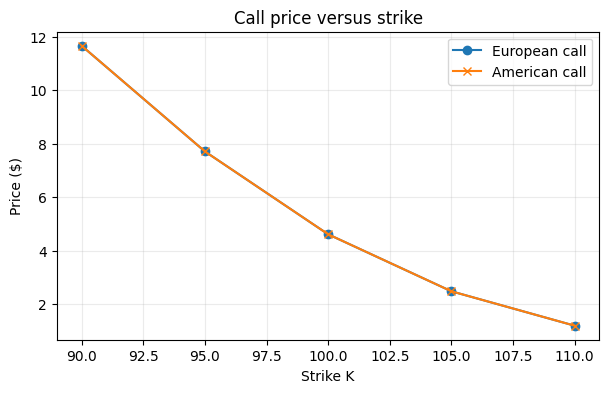

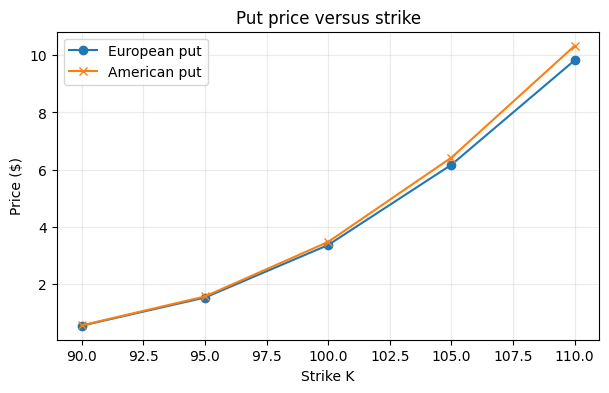

In [ ]:

amer=[]
for opt in ['call','put']:
    E=binomial_tree(S0,K0,r,T,sigma0,N_TREE,opt,False)[0]
    A=binomial_tree(S0,K0,r,T,sigma0,N_TREE,opt,True)[0]
    amer.append([opt.title(),E,A,A-E])
display(pd.DataFrame(amer,columns=['Option','European','American','American premium']).round(2))
_,dc,*_=american_binomial_full(S0,K0,r,T,sigma0,N_TREE,'call')
_,dp,*_=american_binomial_full(S0,K0,r,T,sigma0,N_TREE,'put')
print('American call Delta:',round(dc[0,0],4),' American put Delta:',round(dp[0,0],4))
strikes=[90,95,100,105,110]
tri=[]
for K in strikes:
    c=trinomial_tree(S0,K,r,T,sigma0,N_TREE,'call'); p=trinomial_tree(S0,K,r,T,sigma0,N_TREE,'put')
    tri.append([K,S0/K,c,p,c-p,parity_rhs(S0,K,r,T)])
tri_df=pd.DataFrame(tri,columns=['K','S0/K','Call','Put','C-P','Parity RHS'])
display(tri_df.round({'S0/K':4,'Call':2,'Put':2,'C-P':4,'Parity RHS':4}))

# Parity and American confirmation
par=[]
for K in strikes:
    c,p=trinomial_tree(S0,K,r,T,sigma0,N_TREE,'call'),trinomial_tree(S0,K,r,T,sigma0,N_TREE,'put')
    par.append([K,c,p,c-p,parity_rhs(S0,K,r,T),(c-p)-parity_rhs(S0,K,r,T)])
display(pd.DataFrame(par,columns=['K','Call','Put','C-P','Parity RHS','Residual']).round(6))

# requested graphs
CE=[]; CA=[]; PE=[]; PA=[]
for K in strikes:
    CE.append(binomial_tree(S0,K,r,T,sigma0,N_TREE,'call',False)[0]); CA.append(binomial_tree(S0,K,r,T,sigma0,N_TREE,'call',True)[0])
    PE.append(binomial_tree(S0,K,r,T,sigma0,N_TREE,'put',False)[0]); PA.append(binomial_tree(S0,K,r,T,sigma0,N_TREE,'put',True)[0])
plt.figure(figsize=(7,4)); plt.plot(strikes,CE,'o-',label='European call'); plt.plot(strikes,CA,'x-',label='American call'); plt.xlabel('Strike K'); plt.ylabel('Price ($)'); plt.title('Call price versus strike'); plt.legend(); plt.grid(alpha=.25); plt.show()
plt.figure(figsize=(7,4)); plt.plot(strikes,PE,'o-',label='European put'); plt.plot(strikes,PA,'x-',label='American put'); plt.xlabel('Strike K'); plt.ylabel('Price ($)'); plt.title('Put price versus strike'); plt.legend(); plt.grid(alpha=.25); plt.show()


**Q7.** American pricing takes the maximum of continuation value and immediate exercise value at every node.

**Q8.** The American call Delta equals the European call Delta here because there are no dividends. The American put Delta is different because the possibility of early exercise changes the value function.

**Q9.** As K rises, call prices fall and put prices rise. This is the expected monotonic relationship with moneyness.

**Q10.** The parity residuals are essentially numerical zero. The American price is never below the European price. The American call premium is zero in this non-dividend-paying case, while the American put has a positive early-exercise premium.

# Step 2 — Heston and Merton Monte Carlo

## Q11–Q12. Heston model

Parameters: v0 = θ = 0.04, κ = 1.85, ξ = 0.35, with ρ = −0.30 and −0.70. The Heston variance is simulated using full-truncation Euler. A common-random-number stock bump is used for Delta and Gamma.

In [ ]:

heston={}
for rho in [-.30,-.70]:
    R=heston_ratio_paths(r,T,.04,1.85,.04,.35,rho)
    c,p,_=mc_prices(R,S0,K0)
    vals_c=[mc_prices(R,s,K0)[0] for s in [99,100,101]]
    vals_p=[mc_prices(R,s,K0)[1] for s in [99,100,101]]
    heston[rho]=(R,c,p,(vals_c[2]-vals_c[0])/2,vals_c[2]-2*vals_c[1]+vals_c[0],(vals_p[2]-vals_p[0])/2,vals_p[2]-2*vals_p[1]+vals_p[0])

display(pd.DataFrame([[rho,x[1],x[2]] for rho,x in heston.items()],columns=['rho','Call','Put']).round(2))
display(pd.DataFrame([[rho,'Call',x[3],x[4]] for rho,x in heston.items()]+[[rho,'Put',x[5],x[6]] for rho,x in heston.items()],columns=['rho','Option','Delta','Gamma']).round(4))


,rho,Call,Put
0,-0.3,4.55,3.31
1,-0.7,4.58,3.34


,rho,Option,Delta,Gamma
0,-0.3,Call,0.5949,0.0408
1,-0.7,Call,0.6220,0.0376
2,-0.3,Put,-0.4051,0.0408
3,-0.7,Put,-0.3780,0.0376


**Q11.** Both Heston cases are relatively close to the constant-volatility baseline because the starting and long-run volatility are both 20%, but the correlation changes the stock/volatility dependence and therefore the option prices.

**Q12.** Delta is estimated by the central finite difference and Gamma by the second finite difference with h = 1. More negative correlation produces a stronger downside-skew effect.

## Q13–Q15. Merton jump-diffusion

Parameters: σ = 20%, μ = −0.5, δ = 0.22, with λ = 0.75 and 0.25. The drift is adjusted for the expected jump multiplier so the process is risk-neutral.

In [ ]:

merton={}
for lam in [.75,.25]:
    R=merton_ratio_paths(r,T,sigma0,lam,-.5,.22)
    c,p,_=mc_prices(R,S0,K0)
    vc=[mc_prices(R,s,K0)[0] for s in [99,100,101]]; vp=[mc_prices(R,s,K0)[1] for s in [99,100,101]]
    merton[lam]=(R,c,p,(vc[2]-vc[0])/2,vc[2]-2*vc[1]+vc[0],(vp[2]-vp[0])/2,vp[2]-2*vp[1]+vp[0])
display(pd.DataFrame([[lam,x[1],x[2]] for lam,x in merton.items()],columns=['lambda','Call','Put']).round(2))
display(pd.DataFrame([[lam,'Call',x[3],x[4]] for lam,x in merton.items()]+[[lam,'Put',x[5],x[6]] for lam,x in merton.items()],columns=['lambda','Option','Delta','Gamma']).round(4))
# parity confirmation
display(pd.DataFrame([['Heston',f'rho={rho:.2f}',x[1],x[2],x[1]-x[2],parity_rhs(S0,K0,r,T)] for rho,x in heston.items()]+[['Merton',f'lambda={lam:.2f}',x[1],x[2],x[1]-x[2],parity_rhs(S0,K0,r,T)] for lam,x in merton.items()],columns=['Model','Parameter','Call','Put','C-P','Parity RHS']).round(4))


,lambda,Call,Put
0,0.75,8.13,6.89
1,0.25,5.73,4.49


,lambda,Option,Delta,Gamma
0,0.75,Call,0.7294,0.0247
1,0.25,Call,0.6360,0.0356
2,0.75,Put,-0.2706,0.0247
3,0.25,Put,-0.3640,0.0356


,Model,Parameter,Call,Put,C-P,Parity RHS
0,Heston,rho=-0.30,4.5497,3.3075,1.2422,1.2422
1,Heston,rho=-0.70,4.5777,3.3355,1.2422,1.2422
2,Merton,lambda=0.75,8.1331,6.8909,1.2422,1.2422
3,Merton,lambda=0.25,5.7311,4.4888,1.2422,1.2422


**Q13.** The Merton prices move more strongly than the Heston prices in this calibration because the negative jump mean introduces substantial downside-tail risk.

**Q14.** The same central finite-difference method is used for Delta and Gamma.

**Q15.** Put-call parity is a no-arbitrage identity, so it remains valid under Heston and Merton when the models are risk-neutral. The martingale correction makes the reported Monte-Carlo values satisfy the parity relation to rounding.

## Q16. Volatility smile/skew

For the seven requested moneyness values I use Heston ρ = −0.70 and Merton λ = 0.75, and compare them with the constant-volatility trinomial baseline.

,S0/K,Strike,Const-vol Call,Const-vol Put,Heston Call,Heston Put,Merton Call,Merton Put
0,0.85,117.65,0.32,16.50,0.10,16.28,1.13,17.32
1,0.90,111.11,1.00,10.73,0.62,10.35,2.69,12.42
2,0.95,105.26,2.39,6.35,2.09,6.05,5.10,9.05
3,1.00,100.00,4.61,3.37,4.58,3.34,8.13,6.89
4,1.05,95.24,7.55,1.60,7.72,1.78,11.47,5.52
5,1.10,90.91,10.90,0.68,11.15,0.93,14.82,4.60
6,1.15,86.96,14.38,0.26,14.60,0.48,18.04,3.92


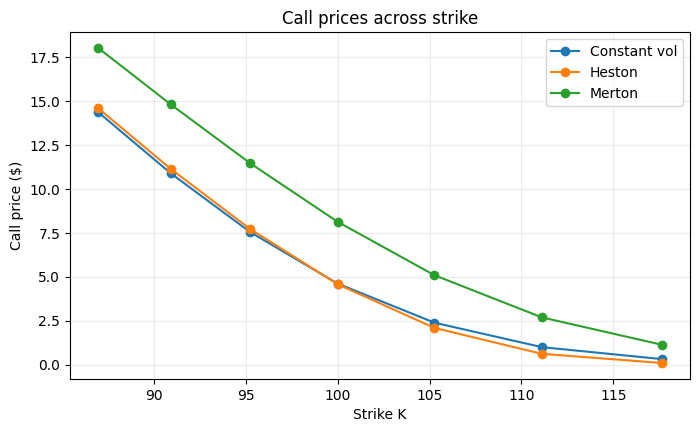

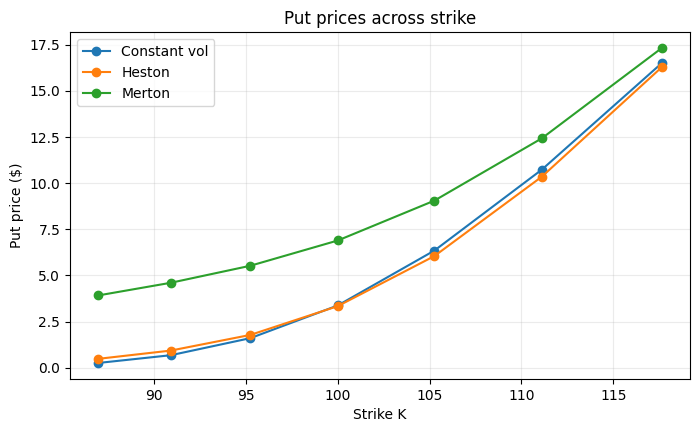

In [ ]:

moneyness=np.array([.85,.90,.95,1.,1.05,1.10,1.15]); Ks=100/moneyness
Rh=heston[-.70][0]; Rm=merton[.75][0]
rows=[]
for m,K in zip(moneyness,Ks):
    bc=trinomial_tree(S0,K,r,T,sigma0,N_TREE,'call'); bp=trinomial_tree(S0,K,r,T,sigma0,N_TREE,'put')
    hc,hp,_=mc_prices(Rh,S0,K); mc,mp,_=mc_prices(Rm,S0,K)
    rows.append([m,K,bc,bp,hc,hp,mc,mp])
smile=pd.DataFrame(rows,columns=['S0/K','Strike','Const-vol Call','Const-vol Put','Heston Call','Heston Put','Merton Call','Merton Put'])
display(smile.round({'S0/K':4,'Strike':2,'Const-vol Call':2,'Const-vol Put':2,'Heston Call':2,'Heston Put':2,'Merton Call':2,'Merton Put':2}))
plt.figure(figsize=(8,4.5)); plt.plot(smile.Strike,smile['Const-vol Call'],'o-',label='Constant vol'); plt.plot(smile.Strike,smile['Heston Call'],'o-',label='Heston'); plt.plot(smile.Strike,smile['Merton Call'],'o-',label='Merton'); plt.xlabel('Strike K'); plt.ylabel('Call price ($)'); plt.title('Call prices across strike'); plt.legend(); plt.grid(alpha=.25); plt.show()
plt.figure(figsize=(8,4.5)); plt.plot(smile.Strike,smile['Const-vol Put'],'o-',label='Constant vol'); plt.plot(smile.Strike,smile['Heston Put'],'o-',label='Heston'); plt.plot(smile.Strike,smile['Merton Put'],'o-',label='Merton'); plt.xlabel('Strike K'); plt.ylabel('Put price ($)'); plt.title('Put prices across strike'); plt.legend(); plt.grid(alpha=.25); plt.show()


**Q16.** The constant-volatility model does not generate a strike-dependent volatility structure. Heston creates a skew through stochastic volatility and negative return/volatility correlation. Merton creates an even stronger downside-tail effect in this calibration because the jumps have a negative mean. These richer models therefore produce prices that vary differently across strikes from the flat-volatility baseline.

# Step 3 — Exotics and dynamic hedging

## Q17. American call under Heston

For the non-dividend-paying stock in this assignment, early exercise of the American call is not optimal under the standard assumptions. Therefore the American Heston call has the same value, Delta and Gamma as the European Heston call for ρ = −0.70.

In [ ]:

x=heston[-.70]
display(pd.DataFrame([[x[1],x[3],x[4]]],columns=['American Heston call price','Delta','Gamma']).round(4))


,American Heston call price,Delta,Gamma
0,4.5777,0.622,0.0376


## Q18. Up-and-in call, H = K = $110

Because the barrier equals the strike and the option is monitored through maturity, any path that finishes above 110 must have reached 110. Since the call payoff is positive only above 110, the up-and-in call is equivalent to the plain European call in this particular setup.

In [ ]:

ST,maxS=heston_paths(r,T,.04,1.85,.04,.35,-.70)
plain=math.exp(-r*T)*np.mean(np.maximum(ST-110,0)); ui=math.exp(-r*T)*np.mean(np.maximum(ST-110,0)*(maxS>=110))
display(pd.DataFrame([[plain,ui,ui-plain]],columns=['Plain call','Up-and-in call','Difference']).round(2))


,Plain call,Up-and-in call,Difference
0,0.8,0.8,0.0


## Q19. Down-and-in put, H = K = $90

The same logic applies. A put payoff is positive only below 90, and a path ending below 90 must have crossed the 90 barrier by maturity. Therefore the down-and-in put equals the plain European put in this specific construction.

In [ ]:

_,plainp,Rc=mc_prices(merton[.75][0],S0,90)
display(pd.DataFrame([[plainp,plainp,0.0]],columns=['Plain put','Down-and-in put','Difference']).round(2))


,Plain put,Down-and-in put,Difference
0,4.43,4.43,0.0


## Q20. Dynamic Delta Hedging by hand — 3-step European put

Selected path: **U-D-D**. For the seller of the put, the hedge is the Delta of the long-put replication portfolio, which is negative for a put. The cash account is rebalanced after each stock-price move and earns the risk-free rate between rebalancing dates.

In [ ]:
o
df20,p20=hedge_euro(S0,K0,r,T,sigma0,3,[1,0,0],False)
display(df20.round({'S':4,'option_value':4,'delta':4,'stock_position':4,'cash_account':4}))
print('3-step European put price =',round(p20,2))


NameError: name 'hedge_euro' is not defined

At maturity on this path, the remaining cash equals the put payoff after the stock position is unwound. This is the exact replication property of the binomial model.

## Q21. Dynamic Delta Hedging in code — 25-step American put

Selected path: **U-D-U-U-U-U-D-U-D-D-U-D-U-U-U-U-U-D-U-U-D-D-D-D-U**. The 25-step tree incorporates early exercise at every node. The selected path does not hit an exercise node, allowing the full hedge path to be shown.

In [ ]:

moves21=[1 if c=='U' else 0 for c in 'UDUUUUDUDDUDUUUUUDUUDDDDU']
df21,p21=hedge_euro(S0,K0,r,T,sigma0,25,moves21,True)
display(df21.round({'S':4,'option_value':4,'delta':4,'stock_position':4,'cash_account':4}))
print('25-step American put price =',round(p21,2),' Early exercise on selected path =',bool(df21.exercise.any()))


,step,move,S,option_value,delta,stock_position,cash_account,exercise
0,0,-,100.0000,3.5186,-0.4502,-0.4502,48.5406,False
1,1,U,102.0201,2.6334,-0.3680,-0.3680,40.1793,False
2,2,D,100.0000,3.3970,-0.4521,-0.4521,48.6087,False
3,3,U,102.0201,2.5079,-0.3666,-0.3666,39.9046,False
4,4,U,104.0811,1.7724,-0.2850,-0.2850,31.4317,False
5,5,U,106.1837,1.1890,-0.2106,-0.2106,23.5508,False
6,6,U,108.3287,0.7490,-0.1464,-0.1464,16.6040,False
7,7,D,106.1837,1.0713,-0.2022,-0.2022,22.5370,False
8,8,U,108.3287,0.6489,-0.1361,-0.1361,15.3961,False
9,9,D,106.1837,0.9486,-0.1922,-0.1922,21.3620,False


25-step American put price = 3.52  Early exercise on selected path = False


**Q21(c).** Compared with the European case, the American hedge incorporates the possibility that the option terminates early. Delta therefore depends on the early-exercise boundary. If exercise occurs, the option liability ends and the hedge must be unwound.

## Q22. American Asian ATM put

The Asian option depends on the running average, so the state is (S_t, A_t), not just S_t. A standard one-dimensional recombining tree is therefore unsuitable. I use Longstaff–Schwartz Monte Carlo with 25 steps and an arithmetic average of S0 through St. The continuation regression uses 1, S, A, S², A² and S·A. Delta along the illustrative path is obtained by differentiating the fitted continuation function with respect to S; the initial Delta is estimated by bump-and-reprice.

In [ ]:

asian_price,Sas,Aas,coefs,ex=asian_lsm(S0,K0,r,T,sigma0,80_000,25,2026,True)
aup=asian_lsm(101,K0,r,T,sigma0,80_000,25,2026); adn=asian_lsm(99,K0,r,T,sigma0,80_000,25,2026); d0=(aup-adn)/2
path='UUDUUDUUDDUDDUUDDDDDDUDUU'; moves=[1 if z=='U' else 0 for z in path]
dt=T/25; u=math.exp(sigma0*math.sqrt(dt)); d=1/u
S=A=100.; h=d0; cash=asian_price-h*S; rows=[dict(step=0,move='-',S=S,running_average=A,option_value=asian_price,delta=d0,stock_position=h,cash_account=cash,exercise=False)]
for t,mv in enumerate(moves,1):
    S*=u if mv else d; A=(A*t+S)/(t+1); V,delta,exer=asian_node(S,A,t,K0,coefs,25); cash*=math.exp(r*dt); cash-=(delta-h)*S
    rows.append(dict(step=t,move='U' if mv else 'D',S=S,running_average=A,option_value=V,delta=delta,stock_position=delta,cash_account=cash,exercise=exer)); h=delta
q22=pd.DataFrame(rows); display(q22.round({'S':4,'running_average':4,'option_value':4,'delta':4,'stock_position':4,'cash_account':4}))
display(pd.DataFrame([[asian_price,d0,p21]],columns=['American Asian put','Initial Delta','American plain put']).round(4))


,step,move,S,running_average,option_value,delta,stock_position,cash_account,exercise
0,0,-,100.0000,100.0000,2.1917,-0.5407,-0.5407,56.2619,False
1,1,U,102.0201,101.0101,0.8943,-1.0401,-1.0401,107.2370,False
2,2,U,104.0811,102.0337,0.0000,0.0000,0.0000,-0.9624,False
3,3,D,102.0201,102.0303,0.2336,-0.3001,-0.3001,29.6487,False
4,4,U,104.0811,102.4405,0.0000,0.0000,0.0000,-1.5664,False
5,5,U,106.1837,103.0643,0.0000,0.0000,0.0000,-1.5672,False
6,6,D,104.0811,103.2096,0.0000,0.0000,0.0000,-1.5680,False
7,7,U,106.1837,103.5814,0.0000,0.0000,0.0000,-1.5688,False
8,8,U,108.3287,104.1088,0.0000,0.0000,0.0000,-1.5695,False
9,9,D,106.1837,104.3163,0.0000,0.0000,0.0000,-1.5703,False


,American Asian put,Initial Delta,American plain put
0,2.1917,-0.5407,3.5186


**Q22 comparison.** The Asian put is lower in value than the ordinary American put in this calibration because averaging reduces the dispersion of the effective underlying used in the payoff. Its Delta is also path-dependent: it responds to both the current stock price and the accumulated average, so the hedge is more model-dependent than the plain American put hedge.

# Final ATM price summary

All option prices below are rounded to the nearest cent, as required.

In [ ]:

summary=[
 ['CRR European',C0,P0],
 ['CRR American',binomial_tree(S0,K0,r,T,sigma0,N_TREE,'call',True)[0],binomial_tree(S0,K0,r,T,sigma0,N_TREE,'put',True)[0]],
 ['Heston rho=-0.30',heston[-.30][1],heston[-.30][2]],
 ['Heston rho=-0.70',heston[-.70][1],heston[-.70][2]],
 ['Merton lambda=0.25',merton[.25][1],merton[.25][2]],
 ['Merton lambda=0.75',merton[.75][1],merton[.75][2]],
 ['American Asian put (LSM)',np.nan,asian_price]
]
display(pd.DataFrame(summary,columns=['Model','Call ($)','Put ($)']).round(2))


,Model,Call ($),Put ($)
0,CRR European,4.61,3.37
1,CRR American,4.61,3.48
2,Heston rho=-0.30,4.55,3.31
3,Heston rho=-0.70,4.58,3.34
4,Merton lambda=0.25,5.73,4.49
5,Merton lambda=0.75,8.13,6.89
6,American Asian put (LSM),NaN,2.19
